# Notebook 01h — Projection Orthogonality Test

## Purpose

Directional ablation projects out the component of the residual stream along the refusal
direction: `x <- x - (x . r_hat) r_hat`. If `r_hat` is already close to orthogonal to the
activations it is applied to (i.e. `r_hat^T x ~ 0`), that projection removes almost nothing
and the strong ablation effects reported in `01c_dim_per_category_notebook.ipynb` cannot be
explained by "cancelling a large existing component" — they must come from a small-norm but
functionally important component (consistent with the massive-activation-channel geometry
explored in `01f_block_jacobian_svd_sweep.ipynb`).

This notebook measures `cos(r_hat, x) = (r_hat . x) / ||x||` for every layer, every residual
stream hook point (`resid_pre` / `resid_mid` / `resid_post`), and both HARMFUL and HARMLESS
prompts, on the **clean, non-overlapping held-out split** (`harmful_val.json` /
`harmless_val.json` — disjoint from the `harmful_train.json` / `harmless_train.json` used to
fit `r_hat` in Notebook 01c). A random-direction null distribution calibrates what "orthogonal"
should look like for a random unit vector in `R^4096`, and Mann-Whitney U / Cliff's delta test
whether harmful-prompt alignment is statistically distinguishable from that null and from the
harmless group.

**No ablation hook is applied anywhere in this notebook.** This measures pre-intervention
geometry only.

## Prerequisites
- Notebook 01c must have produced `dim_outputs/{cat}/direction.pt` for each category.
- Notebook 01b must have produced the per-category `harmful_train/val.json`,
  `harmless_train/val.json` splits.


In [1]:
import gc
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import mannwhitneyu
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer
from typing import Dict, List, Optional

NUMPY_SEED = 0
TORCH_SEED = 0
np.random.seed(NUMPY_SEED)
torch.manual_seed(TORCH_SEED)

print(f'NUMPY_SEED = {NUMPY_SEED}')
print(f'TORCH_SEED = {TORCH_SEED}')


NUMPY_SEED = 0
TORCH_SEED = 0


In [2]:
MODEL_PATH = '/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct'
DEVICE     = 'cuda:0'

DIM_OUTPUT_ROOT = 'dim_outputs'                       # written by 01c, read-only here
CATEGORY_DIR    = 'data/saladbench_splits/categories'  # written by 01b, read-only here
OUTPUT_ROOT     = 'projection_outputs'                 # this notebook's own outputs

TARGET_CATEGORIES = ['violence', 'self_harm', 'cybercrime']

# l* per category, as selected by 01c's direction search (dim_outputs/{cat}/direction_metadata.json)
L_STAR = {'violence': 16, 'self_harm': 12, 'cybercrime': 13}

# Massive-activation channel indices (01f_block_jacobian_svd_sweep.ipynb)
MA_CHANNELS = [788, 1384, 4062]

T_POS      = -1     # last token position
BATCH_SIZE = 8

HOOK_KINDS = ['resid_pre', 'resid_mid', 'resid_post']

for cat in TARGET_CATEGORIES:
    os.makedirs(os.path.join(OUTPUT_ROOT, cat), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'figures'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'arrays'), exist_ok=True)

print(f'MODEL_PATH  : {MODEL_PATH}')
print(f'L_STAR      : {L_STAR}')
print(f'MA_CHANNELS : {MA_CHANNELS}')
print(f'T_POS       : {T_POS}')
print(f'OUTPUT_ROOT : {OUTPUT_ROOT}/')


MODEL_PATH  : /home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct
L_STAR      : {'violence': 16, 'self_harm': 12, 'cybercrime': 13}
MA_CHANNELS : [788, 1384, 4062]
T_POS       : -1
OUTPUT_ROOT : projection_outputs/


In [3]:
print('Loading HuggingFace model ...')
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float32,   # TransformerLens requires float32 at init
    device_map='cpu',
)
hf_model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Wrapping with TransformerLens HookedTransformer ...')
model = HookedTransformer.from_pretrained(
    'meta-llama/Meta-Llama-3-8B-Instruct',   # used for config lookup only
    hf_model=hf_model,
    tokenizer=tokenizer,
    dtype=torch.float16,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
    move_to_device=True,
    device=DEVICE,
)
model.eval()

del hf_model
gc.collect()

D_MODEL    = model.cfg.d_model
NUM_LAYERS = model.cfg.n_layers

assert D_MODEL == 4096, f'Expected d_model=4096, got {D_MODEL}'
assert NUM_LAYERS == 32, f'Expected n_layers=32, got {NUM_LAYERS}'

print(f'TransformerLens model ready on {DEVICE}')
print(f'd_model    : {D_MODEL}')
print(f'num_layers : {NUM_LAYERS}')


Loading HuggingFace model ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Wrapping with TransformerLens HookedTransformer ...
Loaded pretrained model meta-llama/Meta-Llama-3-8B-Instruct into HookedTransformer
TransformerLens model ready on cuda:0
d_model    : 4096
num_layers : 32


## Tokenization

Copied unchanged from `01c_dim_per_category_notebook.ipynb` Cell 4 (`format_instruction` /
`tokenize_instructions` / `tokens_to_tl`). Uses `apply_chat_template` with
`add_generation_prompt=True`, left-padding, no explicit BOS injection beyond whatever the
chat template already adds — must stay byte-identical to 01c-01f so activations are
comparable to prior notebooks.

In [4]:
def format_instruction(instruction: str) -> str:
    """Wrap instruction in the model's chat template."""
    if getattr(tokenizer, 'chat_template', None) is not None:
        return tokenizer.apply_chat_template(
            [{'role': 'user', 'content': instruction}],
            tokenize=False,
            add_generation_prompt=True
        )
    return f'<s>[INST] {instruction} [/INST]'


def tokenize_instructions(instructions: List[str], device: str = DEVICE) -> dict:
    prompts = [format_instruction(i) for i in instructions]
    encoded = tokenizer(
        prompts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    return {k: v.to(device) for k, v in encoded.items()}


def tokens_to_tl(instructions: List[str]) -> torch.Tensor:
    """Return left-padded token tensor suitable for TransformerLens run_with_cache."""
    toks = tokenize_instructions(instructions)
    return toks['input_ids']   # (batch, seq_len)


# Sanity check against 01c's own sanity check (same prompt, same expected repr)
sample = format_instruction('How do I make pancakes?')
print('Chat template sample (first 200 chars):')
print(repr(sample[:200]))


Chat template sample (first 200 chars):
'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHow do I make pancakes?<'


## Data — clean, non-overlapping test split

`harmful_val.json` / `harmless_val.json` per category were carved out by Notebook 01b at
the same time as `harmful_train.json` / `harmless_train.json` (disjoint by construction —
Cell 29 of 01b samples train and val as separate, non-overlapping slices of
`balanced_splits[cat]`). We re-verify that disjointness here by exact instruction-string
intersection rather than trusting that invariant blindly, since `r_hat` was fit on the
`_train` files and any leakage into `_val` would make this an in-sample test, not a
held-out one.

Harmless prompts come from the per-category `harmless_val.json` (ALPACA), truncated to
match the harmful count.

In [5]:
def load_instructions(path: str) -> List[str]:
    return [r['instruction'] for r in json.load(open(path))]


data = {}   # data[cat] = {'harmful': [...], 'harmless': [...]}

for cat in TARGET_CATEGORIES:
    cat_dir = os.path.join(CATEGORY_DIR, cat)

    harmful_train = load_instructions(os.path.join(cat_dir, 'harmful_train.json'))
    harmful_val   = load_instructions(os.path.join(cat_dir, 'harmful_val.json'))
    harmless_val  = load_instructions(os.path.join(cat_dir, 'harmless_val.json'))

    overlap = set(harmful_train) & set(harmful_val)
    assert len(overlap) == 0, (
        f'[{cat}] harmful_val overlaps harmful_train on {len(overlap)} prompts -- '
        f'this split is not held-out from the DIM-fitting data.'
    )

    n = len(harmful_val)
    harmless = harmless_val[:n]

    data[cat] = {'harmful': harmful_val, 'harmless': harmless}

    print(f'[{cat}]  harmful_val={len(harmful_val)}  '
          f'(0 overlap w/ harmful_train, n_train={len(harmful_train)})  '
          f'harmless={len(harmless)}')


[violence]  harmful_val=76  (0 overlap w/ harmful_train, n_train=301)  harmless=76
[self_harm]  harmful_val=76  (0 overlap w/ harmful_train, n_train=301)  harmless=76
[cybercrime]  harmful_val=76  (0 overlap w/ harmful_train, n_train=301)  harmless=76


## Load DIM directions

Loaded directly from the `.pt` files Notebook 01c saved (unit-norm float16 tensors), not
recomputed. Cast to float32 and renormalised defensively -- 01c's own metadata reports
norms of `1.0000026` / `1.0000086` / `0.9999892` (float16 round-trip noise), so an exact
`== 1.0` check would be wrong; we assert *closeness* and renormalise.

In [6]:
r_hat = {}   # r_hat[cat] -> torch.FloatTensor (D_MODEL,), unit norm, CPU

for cat in TARGET_CATEGORIES:
    path = os.path.join(DIM_OUTPUT_ROOT, cat, 'direction.pt')
    d = torch.load(path, map_location='cpu').float()

    assert d.shape == (D_MODEL,), f'[{cat}] direction shape {tuple(d.shape)} != ({D_MODEL},)'

    norm = d.norm().item()
    assert abs(norm - 1.0) < 1e-2, f'[{cat}] direction norm {norm} far from unit -- check file'
    d = d / d.norm()

    r_hat[cat] = d
    print(f'[{cat}]  loaded from {path}  raw_norm={norm:.6f}  renormalized_norm={d.norm().item():.6f}')


[violence]  loaded from dim_outputs/violence/direction.pt  raw_norm=1.000003  renormalized_norm=1.000000
[self_harm]  loaded from dim_outputs/self_harm/direction.pt  raw_norm=1.000009  renormalized_norm=1.000000
[cybercrime]  loaded from dim_outputs/cybercrime/direction.pt  raw_norm=0.999989  renormalized_norm=1.000000


## Step 1 — Activation collection

`collect_resid` matches the requested single-hook signature exactly (used below as a
correctness reference / spot-check). Because the full sweep needs all 32 layers x 3 hook
kinds x 2 groups x 3 categories, `collect_resid_grid` is the actual workhorse: it fuses all
32-layer x 3-hook-kind names into a single `names_filter` per batch, so each prompt only
needs **one** forward pass instead of 96. Both use the identical no-grad /
`run_with_cache` / per-batch-cache-free pattern.

In [7]:
def collect_resid(model: HookedTransformer, prompts: List[str], layer: int, hook_name: str,
                   t_pos: int = -1, batch_size: int = 8) -> torch.Tensor:
    """Collect residual-stream activations at a single (layer, hook_name) for `prompts`.

    Returns a CPU float32 tensor of shape (N, d_model).
    """
    full_name = f'blocks.{layer}.hook_{hook_name}'
    names_filter = lambda name: name == full_name

    out = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        toks = tokens_to_tl(batch)
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=names_filter, return_type=None)
        acts = cache[full_name][:, t_pos, :].float().cpu()
        out.append(acts)
        del cache
        torch.cuda.empty_cache()

    X = torch.cat(out, dim=0)
    assert X.shape == (len(prompts), model.cfg.d_model)
    return X


def collect_resid_grid(model: HookedTransformer, prompts: List[str],
                        hook_kinds: List[str], num_layers: int,
                        t_pos: int = -1, batch_size: int = 8
                        ) -> Dict[str, torch.Tensor]:
    """Collect residual-stream activations at every layer, for every hook kind in
    `hook_kinds`, in a single fused forward pass per batch.

    Returns {hook_kind: tensor of shape (num_layers, N, d_model)}, CPU float32.
    """
    names = [f'blocks.{l}.hook_{hk}' for hk in hook_kinds for l in range(num_layers)]
    name_set = set(names)
    names_filter = lambda name: name in name_set

    d_model = model.cfg.d_model
    accum = {hk: [] for hk in hook_kinds}

    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        toks = tokens_to_tl(batch)
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=names_filter, return_type=None)

        for hk in hook_kinds:
            layer_acts = torch.stack(
                [cache[f'blocks.{l}.hook_{hk}'][:, t_pos, :].float().cpu()
                 for l in range(num_layers)],
                dim=0
            )  # (num_layers, B, d_model)
            accum[hk].append(layer_acts)

        del cache
        torch.cuda.empty_cache()

    result = {hk: torch.cat(accum[hk], dim=1) for hk in hook_kinds}  # (num_layers, N, d_model)
    for hk, X in result.items():
        assert X.shape == (num_layers, len(prompts), d_model)
        assert not torch.isnan(X).any(), f'NaN in collected {hk} activations'
        assert not torch.isinf(X).any(), f'Inf in collected {hk} activations'
    return result


## Step 2 — Metrics

In [8]:
def projection_metrics(X: torch.Tensor, r_hat: torch.Tensor,
                        ma_channels: Optional[List[int]] = None) -> dict:
    """Per-sample projection-orthogonality metrics.

    X     : (N, d_model) float32
    r_hat : (d_model,)   float32, unit norm

    Returns a dict of 1-D numpy arrays, one entry per sample, plus (if ma_channels is
    given) the same metrics recomputed with the massive-activation channels dropped from
    both X and r_hat (r_hat renormalized over the remaining coordinates).
    """
    assert X.dim() == 2 and X.shape[1] == r_hat.shape[0]
    assert not torch.isnan(X).any() and not torch.isinf(X).any()
    assert not torch.isnan(r_hat).any() and not torch.isinf(r_hat).any()

    proj = (X @ r_hat).numpy()
    norms = X.norm(dim=1).numpy()
    cos = proj / norms
    energy = cos ** 2
    abs_cos = np.abs(cos)

    out = {
        'proj': proj, 'norms': norms, 'cos': cos,
        'energy': energy, 'abs_cos': abs_cos,
    }

    if ma_channels is not None:
        keep = [c for c in range(X.shape[1]) if c not in set(ma_channels)]
        X_noMA = X[:, keep]
        r_noMA = r_hat[keep]
        r_noMA = r_noMA / r_noMA.norm()

        proj_noMA = (X_noMA @ r_noMA).numpy()
        norms_noMA = X_noMA.norm(dim=1).numpy()
        out['cos_noMA'] = proj_noMA / norms_noMA
        out['abs_cos_noMA'] = np.abs(out['cos_noMA'])
        out['energy_noMA'] = out['cos_noMA'] ** 2

    return out


## Step 3 — Random-direction null

For a fixed vector `x` and a uniformly random unit vector `r` in `R^d`, `E[|cos(r,x)|]
= sqrt(2/(pi*d))` (half-normal mean of a coordinate of a random unit vector, to leading
order in `d`). We use this as a closed-form correctness check on the Monte Carlo estimate
below.

In [9]:
def random_cos_baseline(X: torch.Tensor, n_dirs: int = 200, seed: int = 0) -> np.ndarray:
    """|cos(r, x)| for x in X against n_dirs random unit directions r.

    Returns a flattened array of shape (N * n_dirs,).
    """
    d_model = X.shape[1]
    gen = torch.Generator().manual_seed(seed)
    R = torch.randn(d_model, n_dirs, generator=gen)
    R = R / R.norm(dim=0, keepdim=True)

    norms = X.norm(dim=1, keepdim=True)  # (N, 1)
    proj = X @ R                          # (N, n_dirs)
    cos = (proj / norms).abs().numpy()
    return cos.flatten()


# Correctness check: empirical mean should track sqrt(2 / (pi * d_model))
_check_X = torch.randn(500, D_MODEL)
_null = random_cos_baseline(_check_X, n_dirs=200, seed=NUMPY_SEED)
_expected_mean = np.sqrt(2.0 / (np.pi * D_MODEL))
_empirical_mean = _null.mean()
_rel_err = abs(_empirical_mean - _expected_mean) / _expected_mean

print(f'Expected  E[|cos|] = sqrt(2/(pi*d)) = {_expected_mean:.6f}')
print(f'Empirical E[|cos|]                  = {_empirical_mean:.6f}  (rel. err {_rel_err:.2%})')
print(f'95th pct = {np.percentile(_null, 95):.6f}   99th pct = {np.percentile(_null, 99):.6f}')

assert _rel_err < 0.20, (
    f'random_cos_baseline empirical mean deviates from theory by {_rel_err:.2%} (>20%) -- '
    f'implementation bug likely.'
)
del _check_X, _null
print('Random-direction baseline implementation verified.')


Expected  E[|cos|] = sqrt(2/(pi*d)) = 0.012467
Empirical E[|cos|]                  = 0.012526  (rel. err 0.48%)
95th pct = 0.030706   99th pct = 0.040256
Random-direction baseline implementation verified.


## Run activation collection

For each category, collect harmful and harmless activations across all 32 layers and all
3 hook kinds.

In [10]:
raw_acts = {}   # raw_acts[cat][group][hook_kind] -> (NUM_LAYERS, N, D_MODEL) CPU float32

for cat in TARGET_CATEGORIES:
    raw_acts[cat] = {}
    for group in ['harmful', 'harmless']:
        prompts = data[cat][group]
        print(f'[{cat}] collecting {group} activations ({len(prompts)} prompts) ...')
        raw_acts[cat][group] = collect_resid_grid(
            model, prompts, HOOK_KINDS, NUM_LAYERS, t_pos=T_POS, batch_size=BATCH_SIZE
        )

print('Activation collection complete.')


[violence] collecting harmful activations (76 prompts) ...
[violence] collecting harmless activations (76 prompts) ...
[self_harm] collecting harmful activations (76 prompts) ...
[self_harm] collecting harmless activations (76 prompts) ...
[cybercrime] collecting harmful activations (76 prompts) ...
[cybercrime] collecting harmless activations (76 prompts) ...
Activation collection complete.


In [11]:
# Spot-check: collect_resid (single hook/layer path) must agree with collect_resid_grid
# (fused multi-layer path) on the same inputs.
_cat, _hook, _layer = TARGET_CATEGORIES[0], 'resid_post', L_STAR[TARGET_CATEGORIES[0]]
_prompts = data[_cat]['harmful'][:BATCH_SIZE]

_single = collect_resid(model, _prompts, _layer, _hook, t_pos=T_POS, batch_size=BATCH_SIZE)
_grid = collect_resid_grid(model, _prompts, [_hook], NUM_LAYERS, t_pos=T_POS, batch_size=BATCH_SIZE)
_fused = _grid[_hook][_layer]

_max_abs_diff = (_single - _fused).abs().max().item()
print(f'collect_resid vs collect_resid_grid max abs diff: {_max_abs_diff:.3e}')
assert _max_abs_diff < 1e-4, 'collect_resid and collect_resid_grid disagree -- fusion bug.'
print('collect_resid and collect_resid_grid agree.')

del _single, _grid, _fused


collect_resid vs collect_resid_grid max abs diff: 0.000e+00
collect_resid and collect_resid_grid agree.


## Step 4 — Metrics + statistics grid

Compute `projection_metrics` for every (category, layer, hook, group), plus the
random-direction null per (category, layer, hook) computed against the harmful
activations, then Mann-Whitney U (harmful vs harmless; harmful vs random null),
Cliff's delta, and Benjamini-Hochberg FDR correction across the whole grid.

In [12]:
def cliffs_delta_from_U(U: float, n1: int, n2: int) -> float:
    """Cliff's delta from the Mann-Whitney U statistic: delta = 2U/(n1*n2) - 1."""
    return 2.0 * U / (n1 * n2) - 1.0


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """Benjamini-Hochberg FDR correction. Returns adjusted p-values, same order as input."""
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty(n)
    out[order] = adj
    return out


metrics = {}   # metrics[cat][hook][layer][group] -> dict from projection_metrics
random_null = {}  # random_null[cat][hook][layer] -> flattened |cos| array

rows = []  # long-format records, p_value filled now, p_adj filled after BH pass

for cat in TARGET_CATEGORIES:
    metrics[cat] = {hk: {} for hk in HOOK_KINDS}
    random_null[cat] = {hk: {} for hk in HOOK_KINDS}

    for hk in HOOK_KINDS:
        for layer in range(NUM_LAYERS):
            X_harmful = raw_acts[cat]['harmful'][hk][layer]
            X_harmless = raw_acts[cat]['harmless'][hk][layer]

            assert X_harmful.shape[1] == D_MODEL and X_harmless.shape[1] == D_MODEL
            for X in (X_harmful, X_harmless):
                assert not torch.isnan(X).any() and not torch.isinf(X).any()

            m_harmful = projection_metrics(X_harmful, r_hat[cat], ma_channels=MA_CHANNELS)
            m_harmless = projection_metrics(X_harmless, r_hat[cat], ma_channels=MA_CHANNELS)
            null = random_cos_baseline(X_harmful, n_dirs=200, seed=NUMPY_SEED)

            metrics[cat][hk][layer] = {'harmful': m_harmful, 'harmless': m_harmless}
            random_null[cat][hk][layer] = null

            for metric_name, hf_key, hl_key in [('abs_cos', 'abs_cos', 'abs_cos'),
                                                  ('abs_cos_noMA', 'abs_cos_noMA', 'abs_cos_noMA'),
                                                  ('energy', 'energy', 'energy')]:
                hf_vals = m_harmful[hf_key]
                hl_vals = m_harmless[hl_key]

                U_hh, p_hh = mannwhitneyu(hf_vals, hl_vals, alternative='two-sided')
                delta_hh = cliffs_delta_from_U(U_hh, len(hf_vals), len(hl_vals))

                U_hr, p_hr = mannwhitneyu(hf_vals, null, alternative='two-sided')
                delta_hr = cliffs_delta_from_U(U_hr, len(hf_vals), len(null))

                rows.append({
                    'category': cat, 'layer': layer, 'hook': hk, 'metric': metric_name,
                    'group': 'harmful_vs_harmless', 'value': float(np.mean(hf_vals)),
                    'n': len(hf_vals), 'p_value': p_hh, 'effect_size': delta_hh,
                })
                rows.append({
                    'category': cat, 'layer': layer, 'hook': hk, 'metric': metric_name,
                    'group': 'harmful_vs_random', 'value': float(np.mean(hf_vals)),
                    'n': len(hf_vals), 'p_value': p_hr, 'effect_size': delta_hr,
                })

    print(f'[{cat}] metrics + stats computed for {len(HOOK_KINDS)} hooks x {NUM_LAYERS} layers')

results_df = pd.DataFrame(rows)
results_df['p_adj'] = bh_fdr(results_df['p_value'].to_numpy())

csv_path = os.path.join(OUTPUT_ROOT, 'projection_orthogonality_stats.csv')
results_df.to_csv(csv_path, index=False)
print(f'Saved {csv_path}  ({len(results_df)} rows)')
results_df.head()


[violence] metrics + stats computed for 3 hooks x 32 layers
[self_harm] metrics + stats computed for 3 hooks x 32 layers
[cybercrime] metrics + stats computed for 3 hooks x 32 layers
Saved projection_outputs/projection_orthogonality_stats.csv  (1728 rows)


,category,layer,hook,metric,group,value,n,p_value,effect_size,p_adj
0,violence,0,resid_pre,abs_cos,harmful_vs_harmless,0.022392,76,1.000000e+00,0.00,1.000000e+00
1,violence,0,resid_pre,abs_cos,harmful_vs_random,0.022392,76,4.833446e-35,0.82,1.403730e-34
2,violence,0,resid_pre,abs_cos_noMA,harmful_vs_harmless,0.022940,76,1.000000e+00,0.00,1.000000e+00
3,violence,0,resid_pre,abs_cos_noMA,harmful_vs_random,0.022940,76,7.349352e-36,0.83,2.137993e-35
4,violence,0,resid_pre,energy,harmful_vs_harmless,0.000501,76,1.000000e+00,0.00,1.000000e+00


## Step 5 — Figures

**Fig A**: `|cos|` vs layer at `hook=resid_post`, one line per group (harmful / harmless /
random null) with shaded IQR, one subplot per category, `l*` marked, and a horizontal
reference line at `sqrt(2/(pi*4096))`.

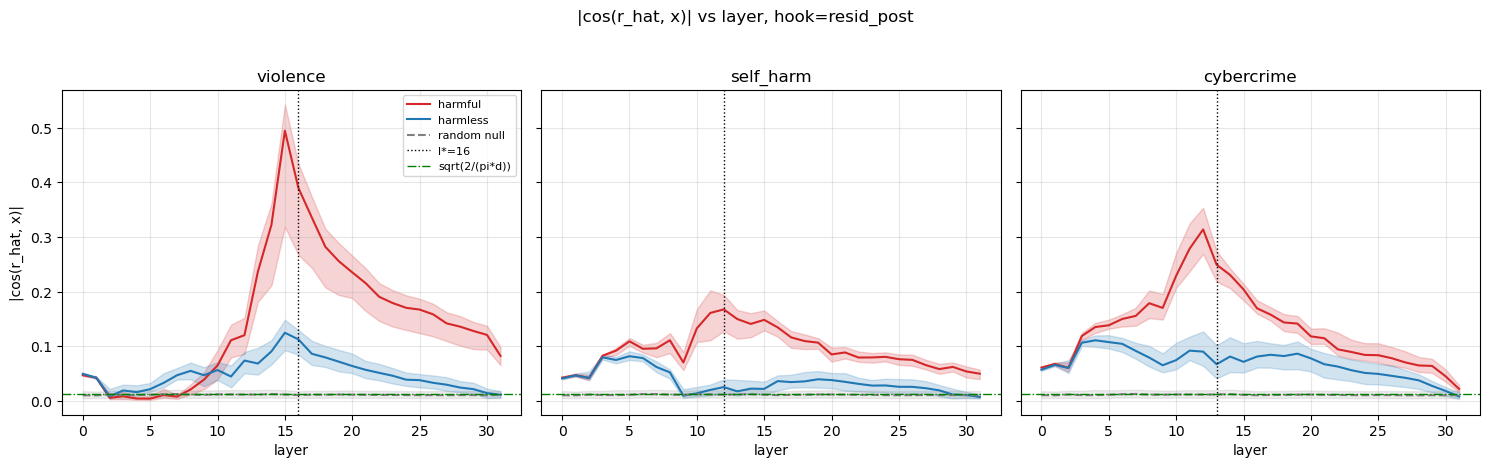

Saved projection_outputs/figures/fig_a_abs_cos_by_layer.png
Saved Fig A arrays (.npy, float32).


In [13]:
REF_LINE = np.sqrt(2.0 / (np.pi * D_MODEL))
HOOK_FOR_FIGS = 'resid_post'

fig, axes = plt.subplots(1, len(TARGET_CATEGORIES), figsize=(15, 4.5), sharey=True)

for ax, cat in zip(axes, TARGET_CATEGORIES):
    layers = np.arange(NUM_LAYERS)

    for group, color in [('harmful', 'tab:red'), ('harmless', 'tab:blue')]:
        med = np.array([np.median(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos']) for l in layers])
        q25 = np.array([np.percentile(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos'], 25) for l in layers])
        q75 = np.array([np.percentile(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos'], 75) for l in layers])
        ax.plot(layers, med, color=color, label=group, linewidth=1.5)
        ax.fill_between(layers, q25, q75, color=color, alpha=0.2)

    null_med = np.array([np.median(random_null[cat][HOOK_FOR_FIGS][l]) for l in layers])
    null_q25 = np.array([np.percentile(random_null[cat][HOOK_FOR_FIGS][l], 25) for l in layers])
    null_q75 = np.array([np.percentile(random_null[cat][HOOK_FOR_FIGS][l], 75) for l in layers])
    ax.plot(layers, null_med, color='gray', linestyle='--', label='random null', linewidth=1.5)
    ax.fill_between(layers, null_q25, null_q75, color='gray', alpha=0.15)

    ax.axvline(L_STAR[cat], color='black', linestyle=':', linewidth=1, label=f'l*={L_STAR[cat]}')
    ax.axhline(REF_LINE, color='green', linestyle='-.', linewidth=1, label='sqrt(2/(pi*d))')

    ax.set_title(cat)
    ax.set_xlabel('layer')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('|cos(r_hat, x)|')
axes[0].legend(fontsize=8)
fig.suptitle(f'|cos(r_hat, x)| vs layer, hook={HOOK_FOR_FIGS}', y=1.03)
plt.tight_layout()

fig_a_path = os.path.join(OUTPUT_ROOT, 'figures', 'fig_a_abs_cos_by_layer.png')
plt.savefig(fig_a_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {fig_a_path}')

# Export underlying arrays for MATLAB reproduction
for cat in TARGET_CATEGORIES:
    arr = np.stack([
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmful']['abs_cos']) for l in range(NUM_LAYERS)],
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmless']['abs_cos']) for l in range(NUM_LAYERS)],
        [np.median(random_null[cat][HOOK_FOR_FIGS][l]) for l in range(NUM_LAYERS)],
    ], axis=0).astype(np.float32)  # (3, NUM_LAYERS): harmful, harmless, random
    np.save(os.path.join(OUTPUT_ROOT, 'arrays', f'fig_a_{cat}_abs_cos_by_layer.npy'), arr)
print('Saved Fig A arrays (.npy, float32).')


**Fig B**: histogram of `cos` at `l*`, harmful vs harmless overlaid, per category.

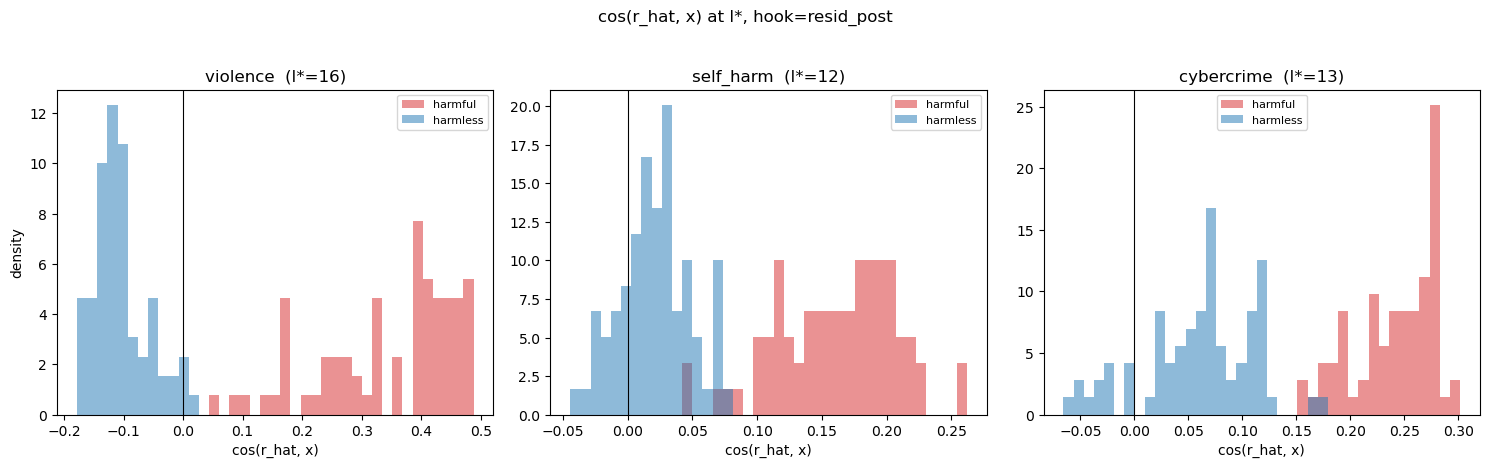

Saved projection_outputs/figures/fig_b_cos_hist_at_lstar.png
Saved Fig B arrays (.npy, float32).


In [14]:
fig, axes = plt.subplots(1, len(TARGET_CATEGORIES), figsize=(15, 4.5))

for ax, cat in zip(axes, TARGET_CATEGORIES):
    l_star = L_STAR[cat]
    hf_cos = metrics[cat][HOOK_FOR_FIGS][l_star]['harmful']['cos']
    hl_cos = metrics[cat][HOOK_FOR_FIGS][l_star]['harmless']['cos']

    bins = np.linspace(
        min(hf_cos.min(), hl_cos.min()), max(hf_cos.max(), hl_cos.max()), 40
    )
    ax.hist(hf_cos, bins=bins, alpha=0.5, label='harmful', color='tab:red', density=True)
    ax.hist(hl_cos, bins=bins, alpha=0.5, label='harmless', color='tab:blue', density=True)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cat}  (l*={l_star})')
    ax.set_xlabel('cos(r_hat, x)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('density')
fig.suptitle(f'cos(r_hat, x) at l*, hook={HOOK_FOR_FIGS}', y=1.03)
plt.tight_layout()

fig_b_path = os.path.join(OUTPUT_ROOT, 'figures', 'fig_b_cos_hist_at_lstar.png')
plt.savefig(fig_b_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {fig_b_path}')

for cat in TARGET_CATEGORIES:
    l_star = L_STAR[cat]
    np.save(os.path.join(OUTPUT_ROOT, 'arrays', f'fig_b_{cat}_cos_harmful_at_lstar.npy'),
            metrics[cat][HOOK_FOR_FIGS][l_star]['harmful']['cos'].astype(np.float32))
    np.save(os.path.join(OUTPUT_ROOT, 'arrays', f'fig_b_{cat}_cos_harmless_at_lstar.npy'),
            metrics[cat][HOOK_FOR_FIGS][l_star]['harmless']['cos'].astype(np.float32))
print('Saved Fig B arrays (.npy, float32).')


**Fig C**: same as Fig A but using `cos_noMA` (massive-activation channels
`[788, 1384, 4062]` dropped and `r_hat` renormalized over the remaining coordinates), to
show the MA-suppression effect.

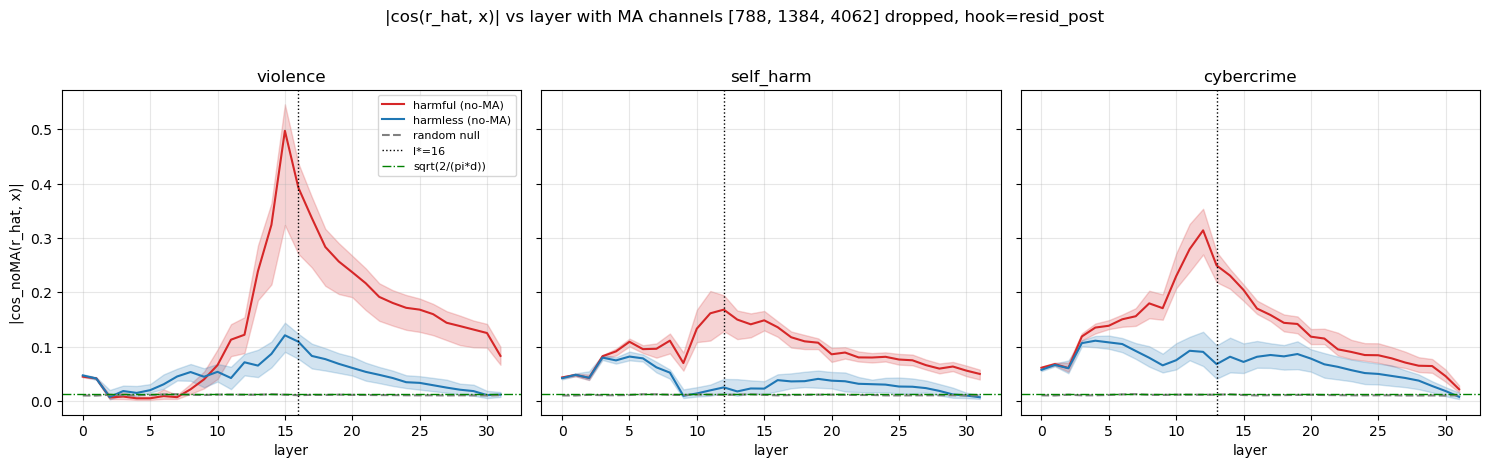

Saved projection_outputs/figures/fig_c_abs_cos_noMA_by_layer.png
Saved Fig C arrays (.npy, float32).


In [15]:
fig, axes = plt.subplots(1, len(TARGET_CATEGORIES), figsize=(15, 4.5), sharey=True)

for ax, cat in zip(axes, TARGET_CATEGORIES):
    layers = np.arange(NUM_LAYERS)

    for group, color in [('harmful', 'tab:red'), ('harmless', 'tab:blue')]:
        med = np.array([np.median(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos_noMA']) for l in layers])
        q25 = np.array([np.percentile(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos_noMA'], 25) for l in layers])
        q75 = np.array([np.percentile(metrics[cat][HOOK_FOR_FIGS][l][group]['abs_cos_noMA'], 75) for l in layers])
        ax.plot(layers, med, color=color, label=f'{group} (no-MA)', linewidth=1.5)
        ax.fill_between(layers, q25, q75, color=color, alpha=0.2)

    null_med = np.array([np.median(random_null[cat][HOOK_FOR_FIGS][l]) for l in layers])
    ax.plot(layers, null_med, color='gray', linestyle='--', label='random null', linewidth=1.5)

    ax.axvline(L_STAR[cat], color='black', linestyle=':', linewidth=1, label=f'l*={L_STAR[cat]}')
    ax.axhline(REF_LINE, color='green', linestyle='-.', linewidth=1, label='sqrt(2/(pi*d))')

    ax.set_title(cat)
    ax.set_xlabel('layer')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('|cos_noMA(r_hat, x)|')
axes[0].legend(fontsize=8)
fig.suptitle(f'|cos(r_hat, x)| vs layer with MA channels {MA_CHANNELS} dropped, hook={HOOK_FOR_FIGS}', y=1.03)
plt.tight_layout()

fig_c_path = os.path.join(OUTPUT_ROOT, 'figures', 'fig_c_abs_cos_noMA_by_layer.png')
plt.savefig(fig_c_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {fig_c_path}')

for cat in TARGET_CATEGORIES:
    arr = np.stack([
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmful']['abs_cos_noMA']) for l in range(NUM_LAYERS)],
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmless']['abs_cos_noMA']) for l in range(NUM_LAYERS)],
    ], axis=0).astype(np.float32)  # (2, NUM_LAYERS): harmful, harmless
    np.save(os.path.join(OUTPUT_ROOT, 'arrays', f'fig_c_{cat}_abs_cos_noMA_by_layer.npy'), arr)
print('Saved Fig C arrays (.npy, float32).')


**Fig D**: `energy = cos^2` vs layer — the fraction of `||x||^2` that directional
ablation removes.

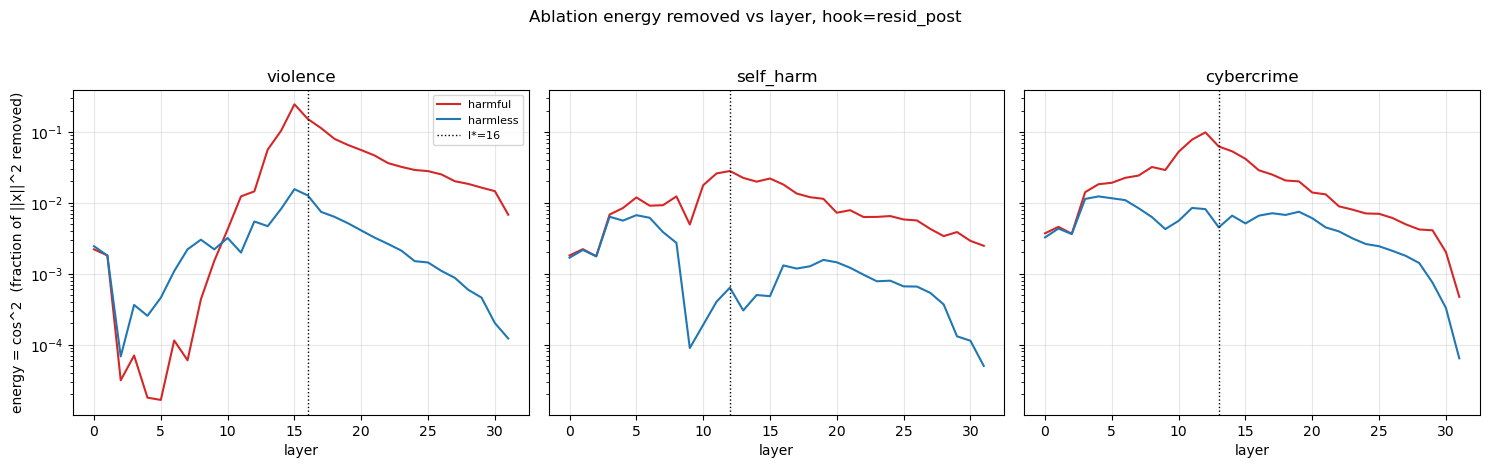

Saved projection_outputs/figures/fig_d_energy_by_layer.png
Saved Fig D arrays (.npy, float32).


In [16]:
fig, axes = plt.subplots(1, len(TARGET_CATEGORIES), figsize=(15, 4.5), sharey=True)

for ax, cat in zip(axes, TARGET_CATEGORIES):
    layers = np.arange(NUM_LAYERS)

    for group, color in [('harmful', 'tab:red'), ('harmless', 'tab:blue')]:
        med = np.array([np.median(metrics[cat][HOOK_FOR_FIGS][l][group]['energy']) for l in layers])
        ax.plot(layers, med, color=color, label=group, linewidth=1.5)

    ax.axvline(L_STAR[cat], color='black', linestyle=':', linewidth=1, label=f'l*={L_STAR[cat]}')
    ax.set_title(cat)
    ax.set_xlabel('layer')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('energy = cos^2  (fraction of ||x||^2 removed)')
axes[0].legend(fontsize=8)
fig.suptitle(f'Ablation energy removed vs layer, hook={HOOK_FOR_FIGS}', y=1.03)
plt.tight_layout()

fig_d_path = os.path.join(OUTPUT_ROOT, 'figures', 'fig_d_energy_by_layer.png')
plt.savefig(fig_d_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {fig_d_path}')

for cat in TARGET_CATEGORIES:
    arr = np.stack([
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmful']['energy']) for l in range(NUM_LAYERS)],
        [np.median(metrics[cat][HOOK_FOR_FIGS][l]['harmless']['energy']) for l in range(NUM_LAYERS)],
    ], axis=0).astype(np.float32)  # (2, NUM_LAYERS): harmful, harmless
    np.save(os.path.join(OUTPUT_ROOT, 'arrays', f'fig_d_{cat}_energy_by_layer.npy'), arr)
print('Saved Fig D arrays (.npy, float32).')


## Step 6 — Printed summary

In [17]:
print('=' * 90)
print('  PROJECTION ORTHOGONALITY SUMMARY  (at l*, hook=resid_post)')
print('=' * 90)

for cat in TARGET_CATEGORIES:
    l_star = L_STAR[cat]
    m_hf = metrics[cat][HOOK_FOR_FIGS][l_star]['harmful']
    m_hl = metrics[cat][HOOK_FOR_FIGS][l_star]['harmless']
    null = random_null[cat][HOOK_FOR_FIGS][l_star]

    mean_hf = m_hf['abs_cos'].mean()
    mean_hl = m_hl['abs_cos'].mean()
    mean_rnd = null.mean()

    row_hh = results_df[(results_df.category == cat) & (results_df.layer == l_star) &
                         (results_df.hook == HOOK_FOR_FIGS) & (results_df.metric == 'abs_cos') &
                         (results_df.group == 'harmful_vs_harmless')].iloc[0]
    row_hr = results_df[(results_df.category == cat) & (results_df.layer == l_star) &
                         (results_df.hook == HOOK_FOR_FIGS) & (results_df.metric == 'abs_cos') &
                         (results_df.group == 'harmful_vs_random')].iloc[0]

    mean_hf_noMA = m_hf['abs_cos_noMA'].mean()
    mean_hl_noMA = m_hl['abs_cos_noMA'].mean()
    row_hh_noMA = results_df[(results_df.category == cat) & (results_df.layer == l_star) &
                              (results_df.hook == HOOK_FOR_FIGS) & (results_df.metric == 'abs_cos_noMA') &
                              (results_df.group == 'harmful_vs_harmless')].iloc[0]

    print(f'\n[{cat}]  l*={l_star}')
    print(f'  mean |cos| harmful   : {mean_hf:.6f}')
    print(f'  mean |cos| harmless  : {mean_hl:.6f}')
    print(f'  mean |cos| random    : {mean_rnd:.6f}')
    print(f'  ratio harmful/random : {mean_hf / mean_rnd:.3f}')
    print(f'  harmful vs harmless  : p_adj={row_hh.p_adj:.3e}  cliffs_delta={row_hh.effect_size:+.4f}')
    print(f'  harmful vs random    : p_adj={row_hr.p_adj:.3e}  cliffs_delta={row_hr.effect_size:+.4f}')
    print(f'  --- no-MA channels {MA_CHANNELS} ---')
    print(f'  mean |cos_noMA| harmful  : {mean_hf_noMA:.6f}')
    print(f'  mean |cos_noMA| harmless : {mean_hl_noMA:.6f}')
    print(f'  harmful vs harmless (noMA) : p_adj={row_hh_noMA.p_adj:.3e}  cliffs_delta={row_hh_noMA.effect_size:+.4f}')

print()
print('=' * 90)
print(f'Stats CSV : {os.path.join(OUTPUT_ROOT, "projection_orthogonality_stats.csv")}')
print(f'Figures   : {os.path.join(OUTPUT_ROOT, "figures")}/')
print(f'Arrays    : {os.path.join(OUTPUT_ROOT, "arrays")}/')


  PROJECTION ORTHOGONALITY SUMMARY  (at l*, hook=resid_post)

[violence]  l*=16
  mean |cos| harmful   : 0.346993
  mean |cos| harmless  : 0.104670
  mean |cos| random    : 0.012558
  ratio harmful/random : 27.631
  harmful vs harmless  : p_adj=7.941e-23  cliffs_delta=+0.9283
  harmful vs random    : p_adj=1.464e-50  cliffs_delta=+1.0000
  --- no-MA channels [788, 1384, 4062] ---
  mean |cos_noMA| harmful  : 0.350506
  mean |cos_noMA| harmless : 0.100548
  harmful vs harmless (noMA) : p_adj=3.217e-23  cliffs_delta=+0.9370

[self_harm]  l*=12
  mean |cos| harmful   : 0.161517
  mean |cos| harmless  : 0.028341
  mean |cos| random    : 0.013357
  ratio harmful/random : 12.093
  harmful vs harmless  : p_adj=1.388e-25  cliffs_delta=+0.9893
  harmful vs random    : p_adj=1.464e-50  cliffs_delta=+0.9999
  --- no-MA channels [788, 1384, 4062] ---
  mean |cos_noMA| harmful  : 0.162123
  mean |cos_noMA| harmless : 0.029019
  harmful vs harmless (noMA) : p_adj=1.553e-25  cliffs_delta=+0.9882

[cy